In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


In [13]:
model = YOLO("best.pt") # 커스텀 yolov8 모델을 사용

model.info() # 모델 정보 출력


Model summary: 295 layers, 25859215 parameters, 0 gradients, 79.1 GFLOPs


(295, 25859215, 0, 79.07850239999999)


image 1/1 /Users/songbeom/final-project/farm-web-python/analysis/notebooks/appleAi/image.png: 480x640 2 100-_ripenesss, 1 rotten_apple, 35.2ms
Speed: 1.3ms preprocess, 35.2ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)
탐지된 객체 개수: 3


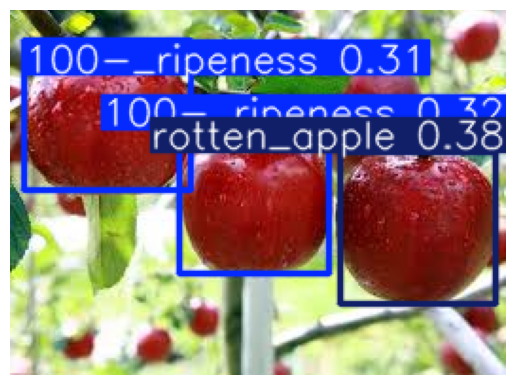

/Users/songbeom/final-project/farm-web-python/myenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/songbeom/final-project/farm-web-python/myenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49472 (\N{HANGUL SYLLABLE SEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/songbeom/final-project/farm-web-python/myenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/songbeom/final-project/farm-web-python/myenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/songbeom/final-project/farm-web-p

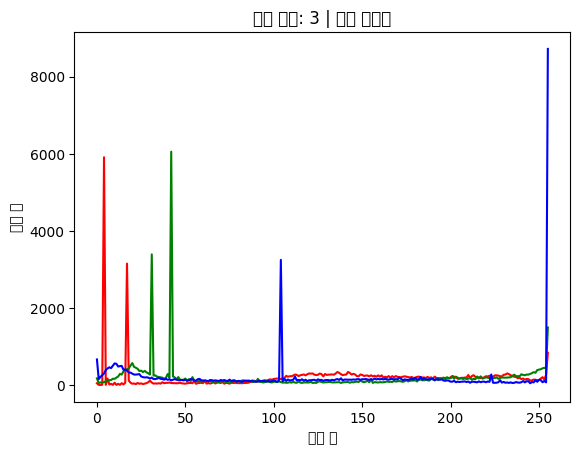

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# YOLO 모델로 객체 탐지
results = model("image.png")

# 탐지된 객체 개수 출력
num_objects = len(results[0].boxes)
print(f"탐지된 객체 개수: {num_objects}")

# 결과 이미지 가져오기
img = results[0].plot()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 색상 분포도 출력 함수
def plot_color_histogram(image):
    colors = ('r', 'g', 'b')
    plt.figure()
    plt.title(f"객체 개수: {num_objects} | 색상 분포도")
    plt.xlabel("픽셀 값")
    plt.ylabel("픽셀 수")

    for i, color in enumerate(colors):
        hist = cv2.calcHist([image], [i], None, [256], [0, 256])
        plt.plot(hist, color=color)

    plt.show()

# 색상 분포도 출력
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

plot_color_histogram(img_rgb)

In [15]:
# YOLO 모델 실행 결과 가져오기
results = model("image.png")

# 탐지된 객체의 클래스 인덱스 가져오기
class_ids = results[0].boxes.cls.cpu().numpy()  # Tensor를 NumPy 배열로 변환

# 클래스별 개수 세기
unique, counts = np.unique(class_ids, return_counts=True)
class_counts = dict(zip(unique, counts))

# 클래스 이름 매핑 (data.yaml의 nc=5 기준)
class_names = results[0].names  # YOLO 모델에서 클래스 이름 가져오기

# 클래스별 개수 출력
print(f"탐지된 객체 총 개수: {len(results[0])}개")
for class_id, count in class_counts.items():
    class_name = class_names[int(class_id)]
    print(f"{class_name}: {count}개")



image 1/1 /Users/songbeom/final-project/farm-web-python/analysis/notebooks/appleAi/image.png: 480x640 4 100-_ripenesss, 78.6ms
Speed: 1.2ms preprocess, 78.6ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)


탐지된 객체 총 개수: 4개
100-_ripeness: 4개



0: 640x640 1 100-_ripeness, 44.0ms
Speed: 1.5ms preprocess, 44.0ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Detected 1 fruits
Bounding Box (24, 49, 191, 207) - Dominant Colors (RGB): [[196 188 234]
 [ 48  38 182]
 [119 117 201]
 [ 47  87  45]
 [ 23  15 117]]
Cluster 0: RGB (196, 188, 234) - HEX #c4bcea
Cluster 1: RGB (48, 38, 182) - HEX #3026b6
Cluster 2: RGB (119, 117, 201) - HEX #7775c9
Cluster 3: RGB (47, 87, 45) - HEX #2f572d
Cluster 4: RGB (23, 15, 117) - HEX #170f75


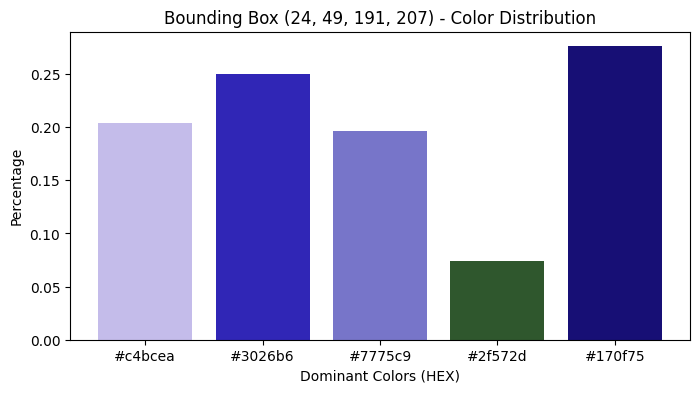

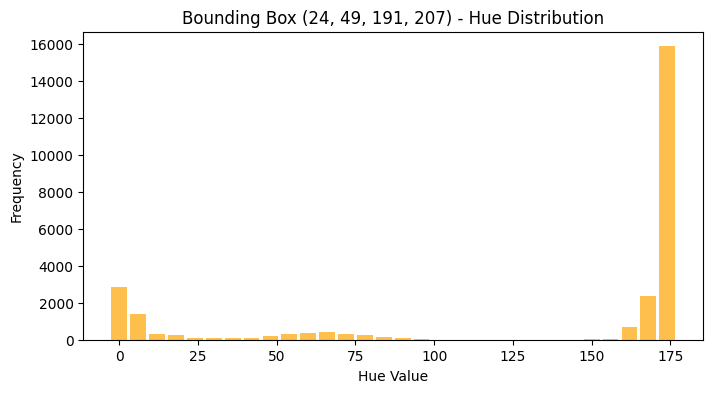

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.cluster import KMeans

# YOLO 모델 로드
model = YOLO("best.pt")  # 사전 학습된 YOLO 모델 사용

# 이미지 로드
image_path = "apple_test.jpg"  # 과일 이미지
image = cv2.imread(image_path)

# YOLO를 이용한 과일 객체 감지
results = model(image)
bounding_boxes = [tuple(map(int, box)) for result in results for box in result.boxes.xyxy]

print(f"Detected {len(bounding_boxes)} fruits")

# ✅ K-means를 이용한 대표 색상 추출 함수
def get_kmeans_colors(image, bbox, k=5):
    x1, y1, x2, y2 = bbox
    cropped = image[y1:y2, x1:x2]  # 바운딩 박스 크롭
    pixels = cropped.reshape(-1, 3)

    # K-means 클러스터링 수행 (결과 안정성을 위해 random_state 추가)
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(pixels)

    # 대표 색상 및 비율 계산
    unique, counts = np.unique(kmeans.labels_, return_counts=True)
    color_distribution = dict(zip(unique, counts / counts.sum()))  # 비율 계산
    dominant_colors = kmeans.cluster_centers_.astype(int)  # 대표 색상

    return dominant_colors, color_distribution

# ✅ RGB 값을 HEX 코드로 변환하는 함수
def rgb_to_hex(color):
    return "#{:02x}{:02x}{:02x}".format(color[0], color[1], color[2])

# ✅ 색상 분포 시각화 (K-means 기반)
def plot_kmeans_colors(dominant_colors, color_distribution, bbox):
    plt.figure(figsize=(8, 4))

    # RGB → HEX 변환
    hex_colors = [rgb_to_hex(color) for color in dominant_colors]

    # RGB 값을 (0~1) 범위로 변환 (Matplotlib에서 요구하는 포맷)
    normalized_colors = [tuple(c/255.0 for c in color) for color in dominant_colors]

    # 바 차트 시각화 (HEX 코드 라벨 추가)
    plt.bar(hex_colors, color_distribution.values(), color=normalized_colors)

    plt.title(f"Bounding Box {bbox} - Color Distribution")
    plt.xlabel("Dominant Colors (HEX)")
    plt.ylabel("Percentage")

    # 색상 정보를 출력
    for i, color in enumerate(dominant_colors):
        print(f"Cluster {i}: RGB {tuple(color)} - HEX {hex_colors[i]}")

    plt.show()

# ✅ HSV 히스토그램 기반 색상 분석 함수
def get_color_histogram(image, bbox):
    x1, y1, x2, y2 = bbox
    cropped = image[y1:y2, x1:x2]  # 바운딩 박스 크롭
    hsv = cv2.cvtColor(cropped, cv2.COLOR_BGR2HSV)
    hue_values = hsv[:, :, 0].flatten()  # Hue 채널 값만 가져옴
    hist, bins = np.histogram(hue_values, bins=30, range=[0, 180])  # Hue 값 히스토그램
    return hist, bins

# ✅ 색상 분포 시각화 (HSV 히스토그램 기반)
def plot_hsv_histogram(hist, bins, bbox):
    plt.figure(figsize=(8, 4))
    plt.bar(bins[:-1], hist, width=5, color="orange", alpha=0.7)  # width 조정으로 가독성 개선
    plt.title(f"Bounding Box {bbox} - Hue Distribution")
    plt.xlabel("Hue Value")
    plt.ylabel("Frequency")
    plt.show()

# 🔥 바운딩 박스별 색상 분석 실행
for bbox in bounding_boxes:
    dominant_colors, color_distribution = get_kmeans_colors(image, bbox)
    hist, bins = get_color_histogram(image, bbox)
    print(f"Bounding Box {bbox} - Dominant Colors (RGB): {dominant_colors}")
    plot_kmeans_colors(dominant_colors, color_distribution, bbox)
    plot_hsv_histogram(hist, bins, bbox) 